## Plant disease classification (CNN)
Run cells top to bottom. **Hyperparameters** are grouped in the first code cell.

In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_path = "Datasets/Assignment_3/train"
valid_path = "Datasets/Assignment_3/valid"
test_path = "Datasets/Assignment_3/test"

# Hyperparameters (single place to change)
IMG_SIZE = (128, 128)
BATCH = 32
EPOCHS = 10

In [2]:
# Train: augment + rescale | Val/Test: rescale only
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)
only_rescale = ImageDataGenerator(rescale=1.0 / 255)

In [3]:
train_data = train_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical"
)
valid_data = only_rescale.flow_from_directory(
    valid_path, target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical"
)
test_data = only_rescale.flow_from_directory(
    test_path, target_size=IMG_SIZE, batch_size=BATCH, class_mode=None, shuffle=False
)
print(train_data.num_classes, "classes — use train_data.class_indices if you need name→index")

Found 22263 images belonging to 38 classes.
Found 3648 images belonging to 38 classes.
Found 33 images belonging to 1 classes.
38 classes — use train_data.class_indices if you need name→index


In [4]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(*IMG_SIZE, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(train_data.num_classes, activation="softmax"))

/opt/homebrew/Cellar/jupyterlab/4.4.0_1/libexec/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(train_data, validation_data=valid_data, epochs=EPOCHS)

Epoch 1/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 246s 351ms/step - accuracy: 0.4645 - loss: 1.6316 - val_accuracy: 0.3753 - val_loss: 7.4523
Epoch 2/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 113s 162ms/step - accuracy: 0.6871 - loss: 0.9169 - val_accuracy: 0.4134 - val_loss: 9.2348
Epoch 3/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 117s 168ms/step - accuracy: 0.7454 - loss: 0.7498 - val_accuracy: 0.4276 - val_loss: 10.6596
Epoch 4/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 130s 187ms/step - accuracy: 0.7932 - loss: 0.6208 - val_accuracy: 0.4076 - val_loss: 10.8626
Epoch 5/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 130s 187ms/step - accuracy: 0.8277 - loss: 0.5166 - val_accuracy: 0.4474 - val_loss: 13.6152
Epoch 6/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 128s 184ms/step - accuracy: 0.8466 - loss: 0.4512 - val_accuracy: 0.4592 - val_loss: 16.2533
Epoch 7/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 128s 184ms/step - accuracy: 0.8637 - loss: 0.4078 - val_accuracy: 0.4698 - val_loss: 13.8510
Epoch 8/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 127s 182ms/step - accuracy: 0.8

In [7]:
model.save("plant_disease_cnn_model.keras")
print("Final train acc:", history.history["accuracy"][-1])
print("Final val acc:  ", history.history["val_accuracy"][-1])

Final train acc: 0.8975879549980164
Final val acc:   0.492050439119339


In [8]:
probs = model.predict(test_data, verbose=0)
print("Predictions shape:", probs.shape)
print("Predicted class ids (first 5 images):", probs[:5].argmax(axis=1))

Predictions shape: (33, 38)
Predicted class ids (first 5 images): [2 2 2 2 0]


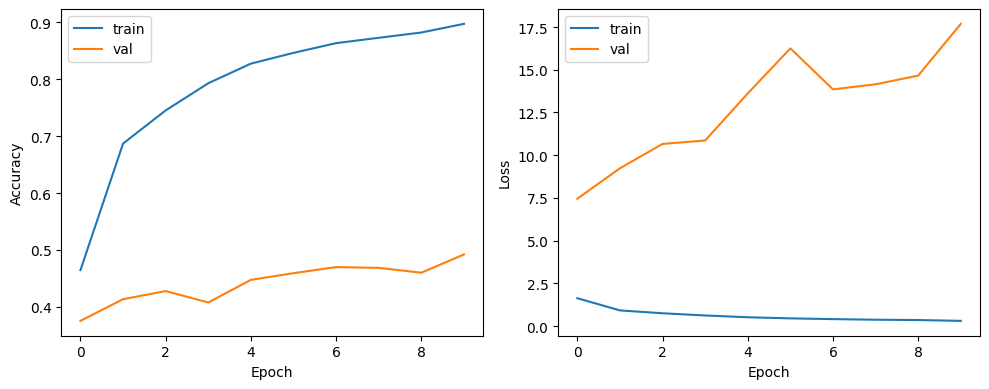

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(history.history["accuracy"], label="train")
ax1.plot(history.history["val_accuracy"], label="val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax2.plot(history.history["loss"], label="train")
ax2.plot(history.history["val_loss"], label="val")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
plt.tight_layout()
plt.show()